In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [3]:
pairwise_df = pd.read_parquet("Outputs/patent_pairwise_similarity.parquet")
pairwise_df.head()

,patent_id_1,patent_id_2,patent_group_1,patent_group_2,patent_thicket_id_1,patent_thicket_id_2,patent_thicket_csv_1,patent_thicket_csv_2,similarity
0,4013523,4062736,205/251,205/251,144.0,144.0,Thicket_002,Thicket_002,0.724479
1,4013523,4075065,205/251,205/251,144.0,144.0,Thicket_002,Thicket_002,0.447742
2,4013523,4168214,205/251,205/251,144.0,144.0,Thicket_002,Thicket_002,0.702994
3,4013523,4192723,205/251,205/251,144.0,NaN,Thicket_002,NaN,0.719929
4,4013523,4199416,205/251,205/251,144.0,NaN,Thicket_002,NaN,0.549678


In [6]:
pairwise_df['same_thicket'] = (
    pairwise_df['patent_thicket_csv_1'] == pairwise_df['patent_thicket_csv_2']
)
pairwise_df.head()

,patent_id_1,patent_id_2,patent_group_1,patent_group_2,patent_thicket_id_1,patent_thicket_id_2,patent_thicket_csv_1,patent_thicket_csv_2,similarity,same_thicket
0,4013523,4062736,205/251,205/251,144.0,144.0,Thicket_002,Thicket_002,0.724479,True
1,4013523,4075065,205/251,205/251,144.0,144.0,Thicket_002,Thicket_002,0.447742,True
2,4013523,4168214,205/251,205/251,144.0,144.0,Thicket_002,Thicket_002,0.702994,True
3,4013523,4192723,205/251,205/251,144.0,NaN,Thicket_002,NaN,0.719929,False
4,4013523,4199416,205/251,205/251,144.0,NaN,Thicket_002,NaN,0.549678,False


Let's plot histogram, which is dependant on being or not in thicket

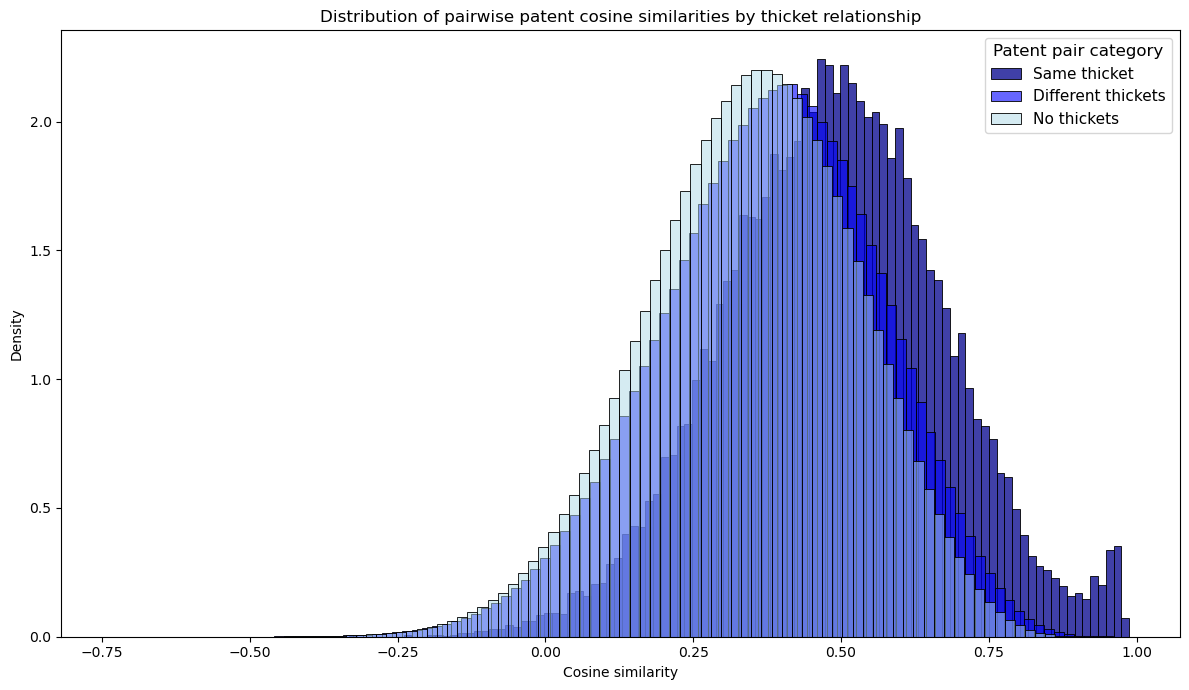

In [4]:
# ===== Definicja przypadków =====

# Czy patent 1 ma thicket
has_thicket_1 = pairwise_df['patent_thicket_csv_1'].notna()

# Czy patent 2 ma thicket
has_thicket_2 = pairwise_df['patent_thicket_csv_2'].notna()

# Oba mają thicket
both_have_thicket = has_thicket_1 & has_thicket_2

# Ten sam thicket
same_thicket = (
    both_have_thicket
    &
    (
        pairwise_df['patent_thicket_csv_1']
        ==
        pairwise_df['patent_thicket_csv_2']
    )
)

# Różne thickety
different_thicket = (
    both_have_thicket
    &
    (
        pairwise_df['patent_thicket_csv_1']
        !=
        pairwise_df['patent_thicket_csv_2']
    )
)

# Co najmniej jeden patent poza thicketem
missing_thicket = ~both_have_thicket


# ===== Wykres =====

fig, ax = plt.subplots(figsize=(12, 7))

# 1. Ten sam thicket -> ciemnoniebieski
sns.histplot(
    pairwise_df.loc[same_thicket, 'similarity'],
    bins=100,
    stat='density',
    color='darkblue',
    alpha=0.75,
    label='Same thicket',
    ax=ax
)

# 2. Różne thickety -> niebieski
sns.histplot(
    pairwise_df.loc[different_thicket, 'similarity'],
    bins=100,
    stat='density',
    color='blue',
    alpha=0.60,
    label='Different thickets',
    ax=ax
)

# 3. Brak thicketu -> jasnoniebieski
sns.histplot(
    pairwise_df.loc[missing_thicket, 'similarity'],
    bins=100,
    stat='density',
    color='lightblue',
    alpha=0.50,
    label='No thickets',
    ax=ax
)


# ===== Opisy =====

ax.set_title(
    'Distribution of pairwise patent cosine similarities by thicket relationship'
)

ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Density')


# ===== Legenda =====

ax.legend(
    title='Patent pair category',
    fontsize=11,
    title_fontsize=12
)



# ===== Layout =====

fig.tight_layout()

fig.savefig(
    'Outputs/patent_similarity_distribution_by_thicket.png',
    dpi=300
)

plt.show()

Calculate basic statistics and tests

In [ ]:
# ===== Statystyki podstawowe =====
case_masks = {
    'Same thicket': same_thicket,
    'Different thickets': different_thicket,
    'No thicket': missing_thicket,
}

basic_stats_records = []
quartile_records = []
for case_name, mask in case_masks.items():
    similarity_values = pairwise_df.loc[mask, 'similarity'].dropna()
    if len(similarity_values):
        quartiles = similarity_values.quantile([0.25, 0.5, 0.75])
    else:
        quartiles = pd.Series([float('nan')] * 3, index=[0.25, 0.5, 0.75])

    basic_stats_records.append({
        'case': case_name,
        'count': len(similarity_values),
        'mean': similarity_values.mean(),
        'std': similarity_values.std(),
        'min': similarity_values.min(),
        '25%': quartiles.loc[0.25],
        '50%': quartiles.loc[0.5],
        '75%': quartiles.loc[0.75],
        'max': similarity_values.max(),
    })
    quartile_records.append({
        'case': case_name,
        'q1': quartiles.loc[0.25],
        'q2': quartiles.loc[0.5],
        'q3': quartiles.loc[0.75],
    })

basic_stats = pd.DataFrame(basic_stats_records)
quartile_table = pd.DataFrame(quartile_records)

results_lines = []
results_lines.append('Basic statistics for each case:')
results_lines.append(basic_stats.to_string(index=False))
results_lines.append('')
results_lines.append('Quartiles of the similarity distribution for each case:')
results_lines.append(quartile_table.to_string(index=False))
results_lines.append('')

print('Basic statistics for each case:')
display(basic_stats)
print('Quartiles of the similarity distribution for each case:')
display(quartile_table)

# ===== Test Walsha =====
def walsh_test(sample_a, sample_b, alternative='two-sided'):
    # Avoid huge O(n*m) memory allocation from np.subtract.outer by counting sign comparisons.
    a = np.asarray(sample_a, dtype=float)
    b = np.asarray(sample_b, dtype=float)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return None

    b_sorted = np.sort(b)
    n_positive = np.searchsorted(b_sorted, a, side='left').sum()
    ties = np.searchsorted(b_sorted, a, side='right') - np.searchsorted(b_sorted, a, side='left')
    n_ties = ties.sum()
    n_pairs = len(a) * len(b) - n_ties
    if n_pairs == 0:
        return None
    return stats.binomtest(n_positive, n_pairs, p=0.5, alternative=alternative)

comparison_pairs = [
    ('Same thicket', 'Different thickets'),
    ('Same thicket', 'No thicket'),
    ('Different thickets', 'No thicket'),
 ]

same_group_mask = pairwise_df['patent_group_1'] == pairwise_df['patent_group_2']
grouped_df = pairwise_df.loc[same_group_mask].copy()
grouped_df['patent_group'] = grouped_df['patent_group_1']

results_lines.append('Walsh test for pairwise mean differences within each patent group:')
print('Walsh test for pairwise mean differences within each patent group:')
for group_name, group_rows in grouped_df.groupby('patent_group', sort=True):
    n_patents = len(pd.unique(group_rows[['patent_id_1', 'patent_id_2']].values.ravel()))
    header = f'Group {group_name}: {n_patents} patents'
    print(header)
    results_lines.append(header)

    group_case_masks = {
        'Same thicket': group_rows['patent_thicket_csv_1'] == group_rows['patent_thicket_csv_2'],
        'Different thickets': (group_rows['patent_thicket_csv_1'].notna() & group_rows['patent_thicket_csv_2'].notna()) & (group_rows['patent_thicket_csv_1'] != group_rows['patent_thicket_csv_2']),
        'No thicket': ~(group_rows['patent_thicket_csv_1'].notna() & group_rows['patent_thicket_csv_2'].notna()),
    }
    for case_name, case_mask in group_case_masks.items():
        line = f'  - {case_name}: {case_mask.sum()} pairs'
        print(line)
        results_lines.append(line)
    for a_name, b_name in comparison_pairs:
        a_values = group_rows.loc[group_case_masks[a_name], 'similarity'].dropna()
        b_values = group_rows.loc[group_case_masks[b_name], 'similarity'].dropna()
        result = walsh_test(a_values.values, b_values.values)
        if result is None:
            line = f'  - {a_name} vs {b_name}: insufficient non-tied pairs'
            print(line)
            results_lines.append(line)
            continue
        mean_diff = a_values.mean() - b_values.mean()
        line = f'  - {a_name} vs {b_name}: mean difference = {mean_diff:.6f}, p-value = {result.pvalue:.3e}, n = {result.n}'
        print(line)
        results_lines.append(line)
    print()
    results_lines.append('')

output_path = 'Outputs/patent_similarity_analysis.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(results_lines))

file_info = os.stat(output_path)
print(f'Results saved to {output_path} ({file_info.st_size:,} bytes)')

Basic statistics for each case:


,case,count,mean,std,min,25%,50%,75%,max
0,Same thicket,29138,0.486239,0.187403,-0.332332,0.360508,0.487766,0.610544,0.987153
1,Different thickets,2924527,0.376190,0.186046,-0.693318,0.254712,0.385303,0.507838,0.976779
2,No thicket,61747335,0.347226,0.179230,-0.732614,0.228927,0.353973,0.473310,0.982637


Quartiles of the similarity distribution for each case:


,case,q1,q2,q3
0,Same thicket,0.360508,0.487766,0.610544
1,Different thickets,0.254712,0.385303,0.507838
2,No thicket,0.228927,0.353973,0.473310


Walsh test for pairwise mean differences within each patent group:
Group 205/251: 26 patents
  - Same thicket: 55 pairs
  - Different thickets: 0 pairs
  - No thicket: 270 pairs
  - Same thicket vs Different thickets: insufficient non-tied pairs
  - Same thicket vs No thicket: mean difference = 0.049925, p-value = 3.696e-148, n = 14850
  - Different thickets vs No thicket: insufficient non-tied pairs

Group 205/564: 47 patents
  - Same thicket: 76 pairs
  - Different thickets: 134 pairs
  - No thicket: 871 pairs
  - Same thicket vs Different thickets: mean difference = 0.122410, p-value = 0.000e+00, n = 10184
  - Same thicket vs No thicket: mean difference = 0.110106, p-value = 0.000e+00, n = 66196
  - Different thickets vs No thicket: mean difference = -0.012304, p-value = 4.618e-144, n = 116714

Group 23/295R: 266 patents
  - Same thicket: 121 pairs
  - Different thickets: 285 pairs
  - No thicket: 34839 pairs
  - Same thicket vs Different thickets: mean difference = 0.075628, p-valu

MemoryError: Unable to allocate 50.1 GiB for an array with shape (13436403396,) and data type float32